# FI-Var (Värriö) – model vs. observations 2015–2018

Comparison of pyAPES simulation (FSM2 snow) and EC flux measurements over the full 4-year period and by growing season.

**Variables:** LE, H, G, GPP, NEE, RECO, Rnet  
**Statistics:** R², RMSE, bias (model − obs) – full period and per growing season (May–Aug)

In [1]:
%matplotlib widget
import os
import sys
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
from dotenv import load_dotenv

load_dotenv('/Users/opa/pyAPES_main/.env')
sys.path.insert(0, '/Users/opa/pyAPES_main')
from pyAPES_utilities.timeseries_tools import diurnal_cycle

NC_PATH  = '/Users/opa/pyAPES_main/results/FI-Var_2015_2018.nc'
EC_PATH  = os.getenv('FI_VAR_EC_PATH')
YEARS    = [2015, 2016, 2017, 2018]
FILL_VALUE = -9999.0

## Load data

In [2]:
# --- NC (model) ---
ds = xr.open_dataset(NC_PATH)
ds_sel = ds.sel(date=ds.date.dt.year.isin(YEARS))
idx_mod = pd.DatetimeIndex(ds_sel.date.values)

def _squeeze(arr):
    return arr[:, 0] if arr.ndim == 2 else arr

model = pd.DataFrame(index=idx_mod, data={
    'LE':   _squeeze(ds_sel['canopy_LE'].values),
    'H':    _squeeze(ds_sel['canopy_SH'].values),
    'G':    _squeeze(ds_sel['ffloor_ground_heat'].values),
    'GPP':  _squeeze(ds_sel['canopy_GPP'].values),
    'NEE':  _squeeze(ds_sel['canopy_NEE'].values),
    'RECO': _squeeze(ds_sel['canopy_Reco'].values),
    'Rnet': _squeeze(ds_sel['canopy_Rnet'].values),
})

# --- EC ---
raw = pd.read_csv(EC_PATH, sep=';', na_values=[FILL_VALUE, -9999])
raw = raw[raw['year'].isin(YEARS)].copy()
raw.index = pd.to_datetime({
    'year': raw['year'], 'month': raw['month'],
    'day': raw['day'], 'hour': raw['hour'], 'minute': raw['minute']
})

obs = pd.DataFrame(index=raw.index, data={
    'LE':   pd.to_numeric(raw['LE'],   errors='coerce'),
    'H':    pd.to_numeric(raw['H'],    errors='coerce'),
    'G':    pd.to_numeric(raw['G'],    errors='coerce'),
    'GPP':  pd.to_numeric(raw['GPP'],  errors='coerce'),
    'NEE':  pd.to_numeric(raw['NEE'],  errors='coerce'),
    'RECO': pd.to_numeric(raw['Reco'], errors='coerce'),
    'Rnet': pd.to_numeric(raw['Rn'],   errors='coerce'),
})

print(f'Model: {model.index[0]} – {model.index[-1]}, n={len(model)}')
print(f'Obs:   {obs.index[0]} – {obs.index[-1]}, n={len(obs)}')

Model: 2015-01-01 00:00:00 – 2018-12-31 00:00:00, n=70081
Obs:   2015-01-01 00:00:00 – 2018-12-31 23:30:00, n=70128


## Statistics functions

In [3]:
VARIABLES = ['LE', 'H', 'G', 'GPP', 'NEE', 'RECO', 'Rnet']
UNITS = {'LE': 'W m⁻²', 'H': 'W m⁻²', 'G': 'W m⁻²',
         'GPP': 'µmol m⁻² s⁻¹', 'NEE': 'µmol m⁻² s⁻¹',
         'RECO': 'µmol m⁻² s⁻¹', 'Rnet': 'W m⁻²'}


def stats_pair(mod, obs):
    """R2, RMSE, bias for paired arrays (NaN-safe)."""
    mask = np.isfinite(mod) & np.isfinite(obs)
    if mask.sum() < 5:
        return dict(n=mask.sum(), R2=np.nan, RMSE=np.nan, bias=np.nan)
    m, o = mod[mask], obs[mask]
    r, _ = stats.pearsonr(m, o)
    return dict(
        n=int(mask.sum()),
        R2=round(r**2, 3),
        RMSE=round(np.sqrt(np.mean((m - o)**2)), 3),
        bias=round(float(np.mean(m - o)), 3),
    )


def align(mod_df, obs_df):
    """Inner-join on index, resample to 30-min if needed."""
    m, o = mod_df.align(obs_df, join='inner')
    return m, o


def growing_season(df):
    return df[(df.index.month >= 5) & (df.index.month <= 8)]

## Statistics table – full period and by growing season

In [4]:
mod_a, obs_a = align(model, obs)

rows = []

# Full period
for var in VARIABLES:
    s = stats_pair(mod_a[var].values, obs_a[var].values)
    rows.append({'period': 'all', 'variable': var, **s})

# Growing season – all years combined
mod_gs = growing_season(mod_a)
obs_gs = growing_season(obs_a)
for var in VARIABLES:
    s = stats_pair(mod_gs[var].values, obs_gs[var].values)
    rows.append({'period': 'gs_all', 'variable': var, **s})

# Growing season – per year
for yr in YEARS:
    m_yr = growing_season(mod_a[mod_a.index.year == yr])
    o_yr = growing_season(obs_a[obs_a.index.year == yr])
    for var in VARIABLES:
        s = stats_pair(m_yr[var].values, o_yr[var].values)
        rows.append({'period': f'gs_{yr}', 'variable': var, **s})

summary = pd.DataFrame(rows).set_index(['period', 'variable'])
summary

n     R2    RMSE    bias
period  variable                              
all     LE        67842  0.693  16.534  -1.360
        H         68720  0.781  32.432 -13.418
        G         64963  0.608   4.664  -1.062
        GPP       70080  0.879   1.007   0.315
        NEE       70080  0.757   1.077   0.243
        RECO      70080  0.885   0.809   0.558
        Rnet      67033  0.894  36.811 -14.889
gs_all  LE        22811  0.708  21.818   0.100
        H         22926  0.870  28.942   0.050
        G         20359  0.839   3.847   0.414
        GPP       23616  0.858   1.428   0.350
        NEE       23616  0.820   1.365  -0.194
        RECO      23616  0.879   0.762   0.156
        Rnet      21968  0.947  33.387   2.284
gs_2015 LE         5841  0.693  20.653   1.330
        H          5844  0.868  28.581   7.113
        G          4535  0.804   4.791   2.540
        GPP        5904  0.854   1.324   0.439
        NEE        5904  0.826   1.257  -0.253
        RECO       5904  0.818   0.815   0.185
        Rnet       4798  0.939  30.503   3.996
gs_2016 LE         5700  0.736  22.518  -1.802
        H          5782  0.877  28.416   5.136
        G          4420  0.854   3.924   0.454
        GPP        5904  0.871   1.413   0.327
        NEE        5904  0.831   1.453  -0.363
        RECO       5904  0.904   0.836  -0.036
        Rnet       5762  0.944  34.601   5.235
gs_2017 LE         5466  0.676  21.636   0.403
        H          5494  0.874  27.302  -3.913
        G          5902  0.877   3.403  -0.616
        GPP        5904  0.861   1.427   0.501
        NEE        5904  0.823   1.229   0.017
        RECO       5904  0.955   0.779   0.517
        Rnet       5904  0.950  32.199  -3.202
gs_2018 LE         5804  0.707  22.424   0.444
        H          5806  0.889  31.238  -8.375
        G          5502  0.886   3.322  -0.266
        GPP        5904  0.841   1.540   0.134
        NEE        5904  0.808   1.501  -0.178
        RECO       5904  0.865   0.593  -0.044
        Rnet       5504  0.957  35.673   3.586

## Time series – 7-day rolling mean

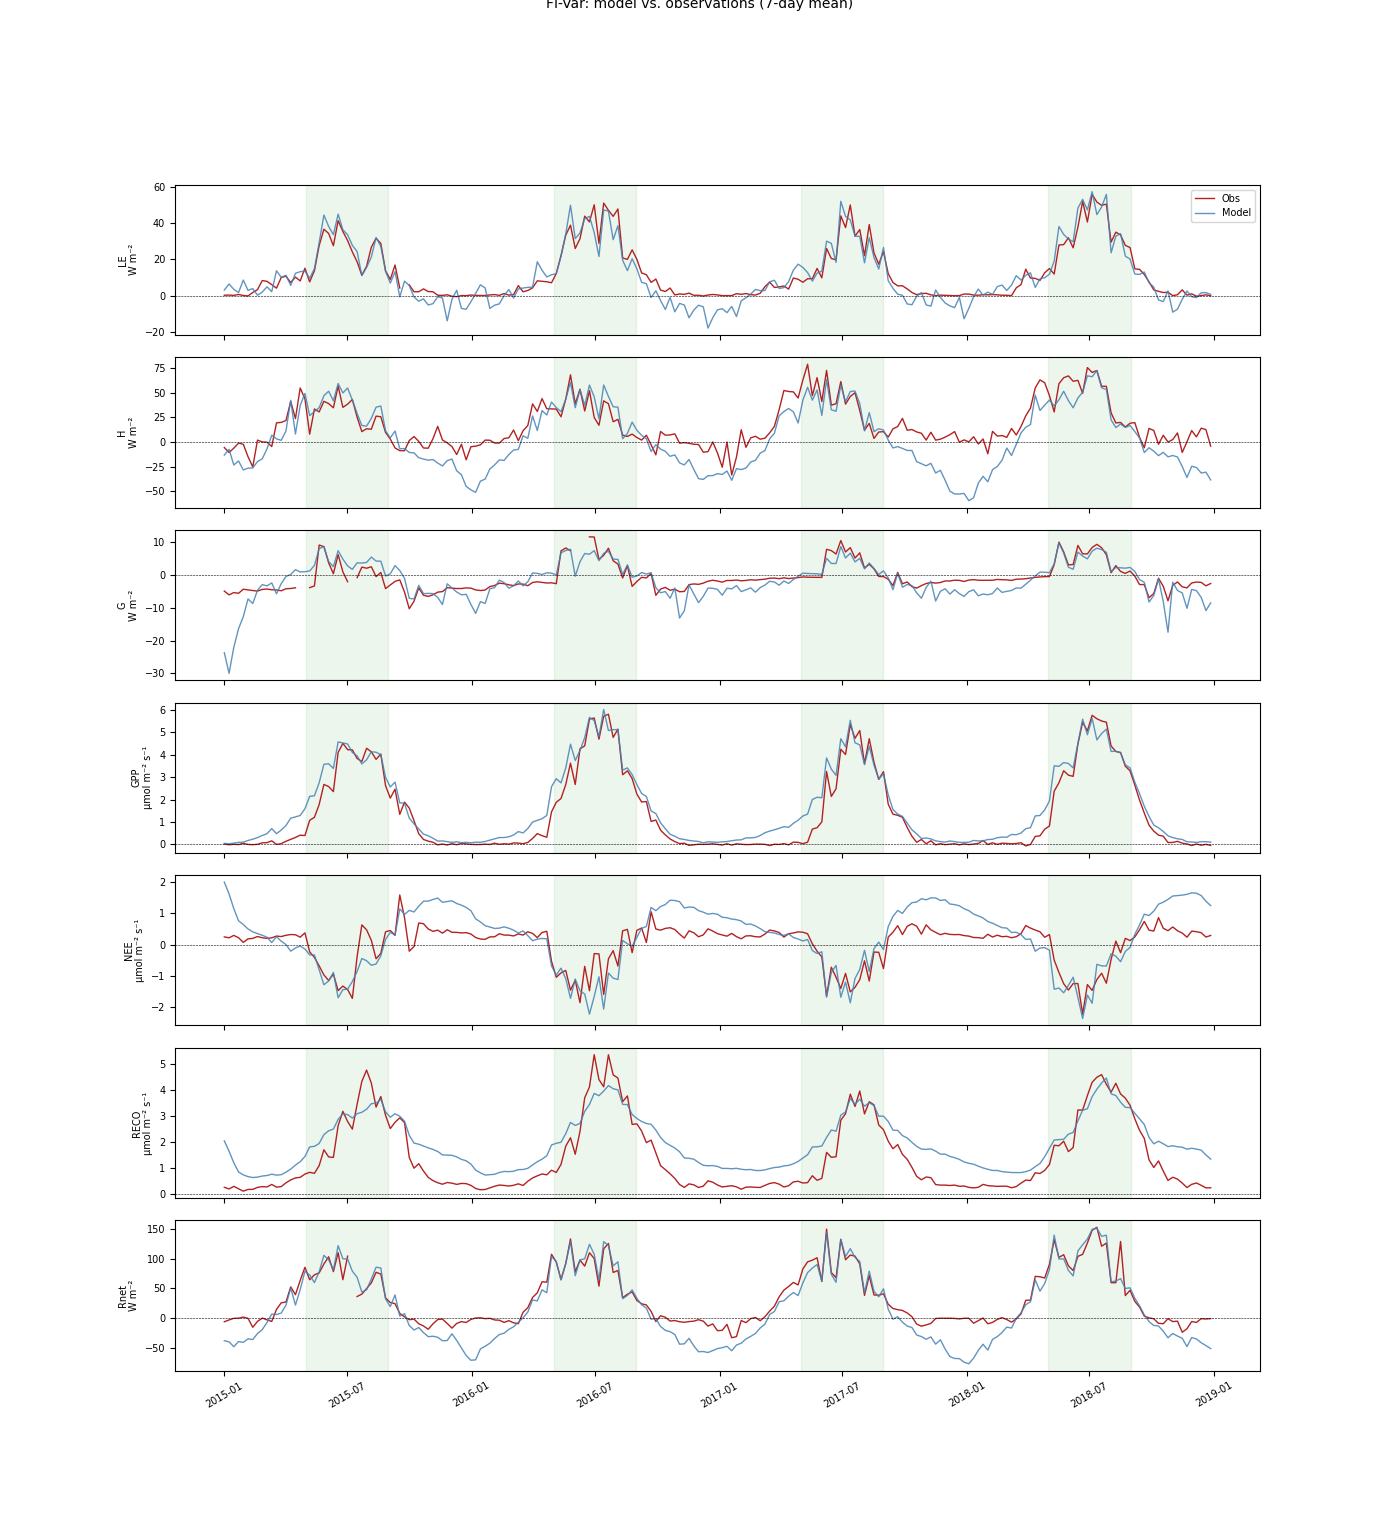

In [5]:
mod_w = mod_a.resample('7D').mean()
obs_w = obs_a.resample('7D').mean()

fig, axes = plt.subplots(len(VARIABLES), 1, figsize=(14, 2.2 * len(VARIABLES)),
                         sharex=True)
fig.subplots_adjust(hspace=0.15)

for ax, var in zip(axes, VARIABLES):
    ax.plot(obs_w.index, obs_w[var], color='firebrick', lw=1.0, label='Obs')
    ax.plot(mod_w.index, mod_w[var], color='steelblue', lw=1.0, label='Model', alpha=0.85)
    ax.set_ylabel(f'{var}\n{UNITS[var]}', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.axhline(0, color='k', lw=0.4, ls='--')
    # shade growing seasons (May–Aug)
    for yr in YEARS:
        ax.axvspan(pd.Timestamp(yr, 5, 1), pd.Timestamp(yr, 8, 31),
                   alpha=0.07, color='green')

axes[0].legend(fontsize=7, loc='upper right')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[-1].tick_params(axis='x', labelrotation=30, labelsize=7)
fig.suptitle('FI-Var: model vs. observations (7-day mean)', fontsize=10, y=1.002)
plt.show()

## Scatter plots – growing season 2015–2018

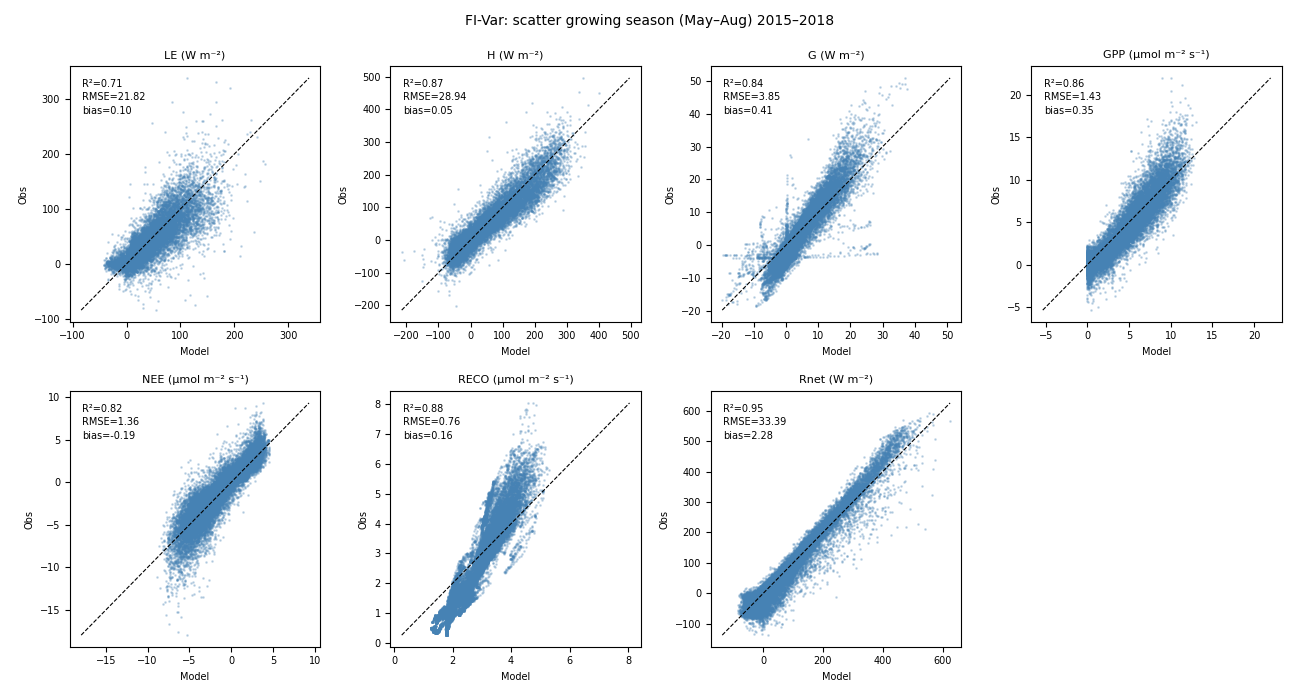

In [6]:
ncols = 4
nrows = int(np.ceil(len(VARIABLES) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.5 * nrows))
axes = axes.flatten()

for i, var in enumerate(VARIABLES):
    ax = axes[i]
    x = mod_gs[var].values
    y = obs_gs[var].values
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 5:
        ax.text(0.5, 0.5, 'no data', transform=ax.transAxes, ha='center', va='center')
        continue
    ax.scatter(x[mask], y[mask], s=1, alpha=0.25, color='steelblue', rasterized=True)
    vmin = min(x[mask].min(), y[mask].min())
    vmax = max(x[mask].max(), y[mask].max())
    ax.plot([vmin, vmax], [vmin, vmax], 'k--', lw=0.8)
    s = stats_pair(x, y)
    ax.text(0.05, 0.95,
            f"R²={s['R2']:.2f}\nRMSE={s['RMSE']:.2f}\nbias={s['bias']:.2f}",
            transform=ax.transAxes, fontsize=7, va='top', linespacing=1.4)
    ax.set_title(f'{var} ({UNITS[var]})', fontsize=8)
    ax.set_xlabel('Model', fontsize=7)
    ax.set_ylabel('Obs', fontsize=7)
    ax.tick_params(labelsize=7)

for ax in axes[len(VARIABLES):]:
    ax.set_visible(False)

fig.suptitle('FI-Var: scatter growing season (May–Aug) 2015–2018', fontsize=10)
fig.tight_layout()
plt.show()

## Growing season statistics per year – bar chart

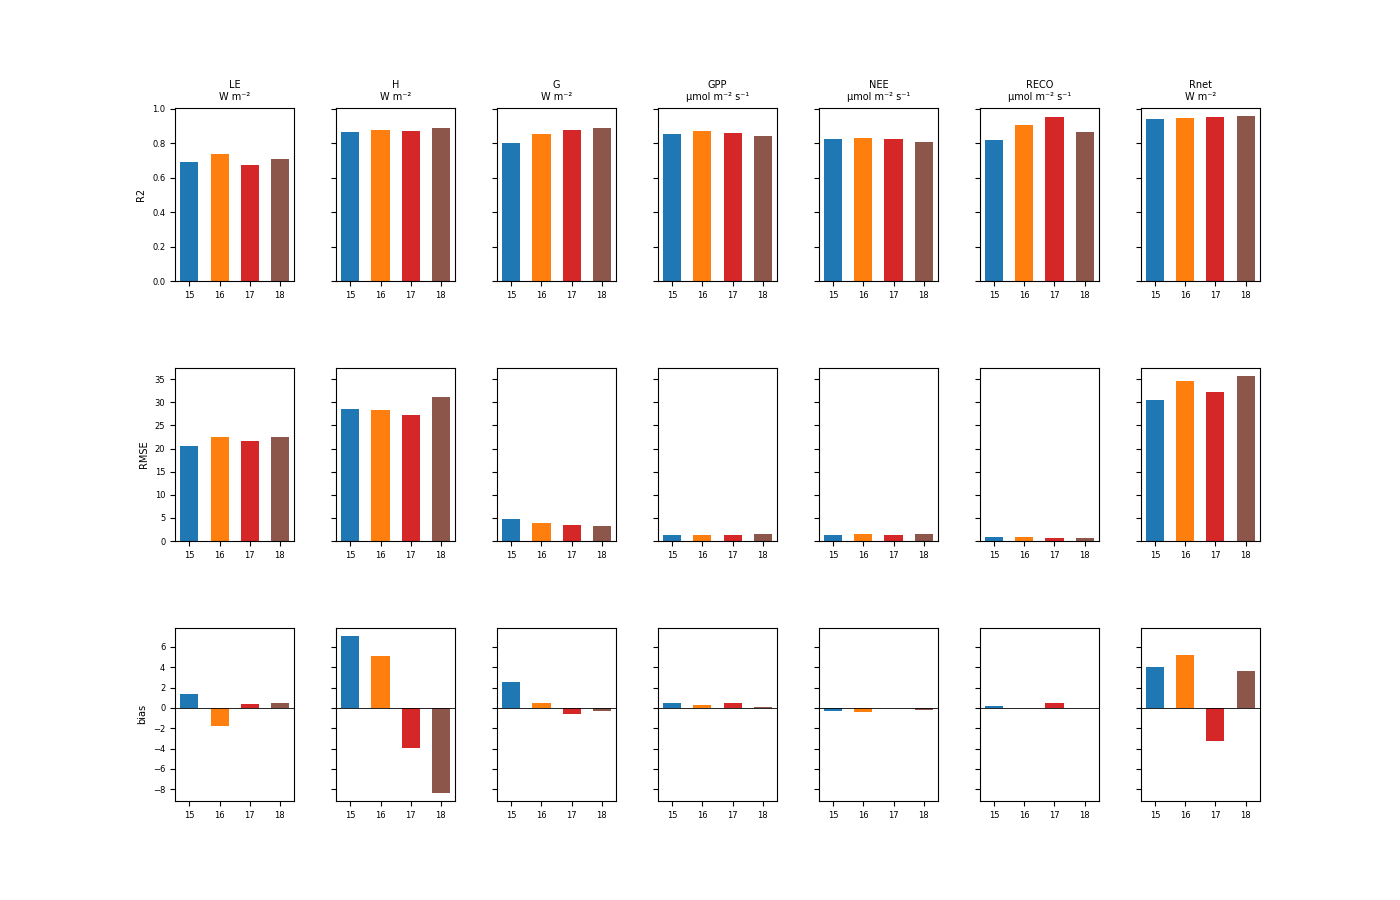

In [7]:
metrics = ['R2', 'RMSE', 'bias']
gs_rows = summary.loc[[f'gs_{yr}' for yr in YEARS]]

fig, axes = plt.subplots(len(metrics), len(VARIABLES),
                         figsize=(14, 3 * len(metrics)), sharey='row')
fig.subplots_adjust(hspace=0.5, wspace=0.35)

colors = plt.cm.tab10(np.linspace(0, 0.5, len(YEARS)))

for col, var in enumerate(VARIABLES):
    for row, metric in enumerate(metrics):
        ax = axes[row, col]
        vals = [gs_rows.loc[(f'gs_{yr}', var), metric] for yr in YEARS]
        ax.bar(YEARS, vals, color=colors, width=0.6)
        if metric in ('RMSE', 'bias'):
            ax.axhline(0, color='k', lw=0.6)
        ax.tick_params(labelsize=6)
        ax.set_xticks(YEARS)
        ax.set_xticklabels([str(y)[2:] for y in YEARS], fontsize=6)
        if col == 0:
            ax.set_ylabel(metric, fontsize=7)
        if row == 0:
            ax.set_title(f'{var}\n{UNITS[var]}', fontsize=7)

fig.suptitle('FI-Var: growing season statistics per year', fontsize=10, y=1.02)
plt.show()